In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# MNIST dataset
from tensorflow.keras.datasets import mnist

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# PCA
from sklearn.decomposition import PCA

# Model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training shape: (60000, 28, 28)
Testing shape: (10000, 28, 28)


In [ ]:
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

print("Flattened shape:", X_train.shape)

Flattened shape: (60000, 784)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model_original = LogisticRegression(max_iter=1000)
model_original.fit(X_train_scaled, y_train)

y_pred_original = model_original.predict(X_test_scaled)
original_accuracy = accuracy_score(y_test, y_pred_original)

print("Accuracy (Original Data):", original_accuracy)

Accuracy (Original Data): 0.9216


In [ ]:
components_list = [2, 10, 30, 50, 100]
accuracy_results = []
variance_results = []

for n in components_list:
    pca = PCA(n_components=n)

    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    explained_variance = np.sum(pca.explained_variance_ratio_)
    variance_results.append(explained_variance)

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_pca, y_train)

    y_pred = model.predict(X_test_pca)
    acc = accuracy_score(y_test, y_pred)
    accuracy_results.append(acc)

    print(f"Components: {n}")
    print(f"Explained Variance: {explained_variance:.4f}")
    print(f"Accuracy: {acc:.4f}")
    print("-------------")

Components: 2
Explained Variance: 0.0972
Accuracy: 0.3413
-------------
Components: 10
Explained Variance: 0.2767
Accuracy: 0.8073
-------------
Components: 30
Explained Variance: 0.4519
Accuracy: 0.8934
-------------
Components: 50
Explained Variance: 0.5511
Accuracy: 0.9046
-------------
Components: 100
Explained Variance: 0.7059
Accuracy: 0.9196
-------------


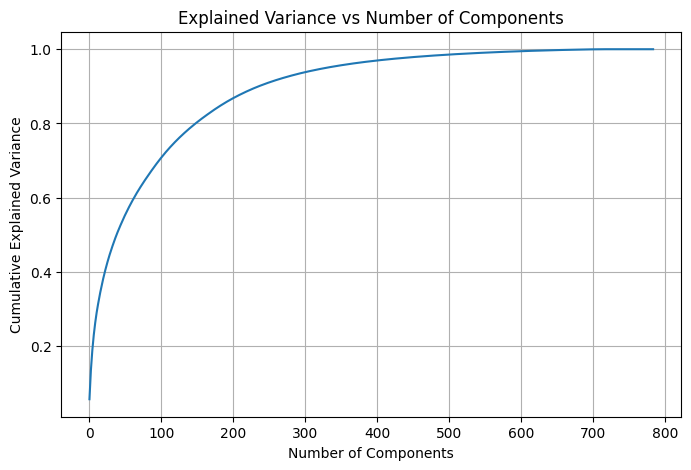

In [ ]:
pca_full = PCA()
pca_full.fit(X_train_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(cumulative_variance)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance vs Number of Components")
plt.grid()
plt.savefig('cumulative_variance.png')
plt.show()

In [ ]:
pca_100 = PCA(n_components=100)
X_train_reduced_100 = pca_100.fit_transform(X_train_scaled)
X_test_reduced_100 = pca_100.transform(X_test_scaled)

print("Reduced shape (50 components):", X_train_reduced_100.shape)

Reduced shape (50 components): (60000, 100)


In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_reduced_100, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test_reduced_100)
reduced_accuracy = accuracy_score(y_test, y_pred)

print(f"Components: {n}")
print(f"Explained Variance: {explained_variance:.4f}")
print(f"Accuracy: {acc:.4f}")

Components: 100
Explained Variance: 0.7059
Accuracy: 0.9196


In [ ]:
model_original = LogisticRegression(max_iter=1000)
model_original.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model_original.predict(X_test_scaled)
original_accuracy = accuracy_score(y_test, y_pred)

print(f"Components: {n}")
print(f"Explained Variance: {explained_variance:.4f}")
print(f"Accuracy: {acc:.4f}")

Components: 100
Explained Variance: 0.7059
Accuracy: 0.9196


In [ ]:
print("========== Accuracy Comparison ==========")
print(f"Original Dataset Accuracy : {original_accuracy:.4f}")
print(f"Reduced Dataset Accuracy  : {reduced_accuracy:.4f}")
print("Difference                 :", round(original_accuracy - reduced_accuracy, 4))

========== Accuracy Comparison ==========
Original Dataset Accuracy : 0.9216
Reduced Dataset Accuracy  : 0.9196
Difference                 : 0.002


In [ ]:
models = ["Original", "Reduced"]
accuracies = [original_accuracy, reduced_accuracy]

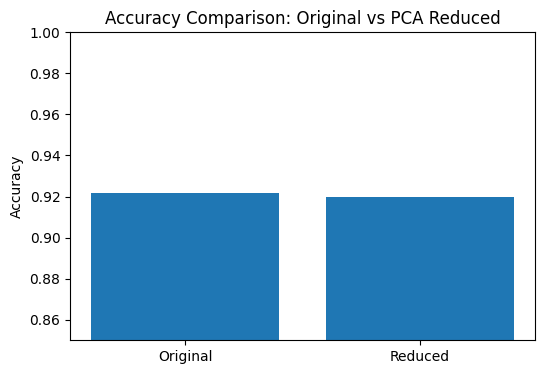

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(models, accuracies)
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison: Original vs PCA Reduced")
plt.ylim(0.85, 1.0)
plt.savefig('accuracy_comparison_org_vs_reduced.png')
plt.show()

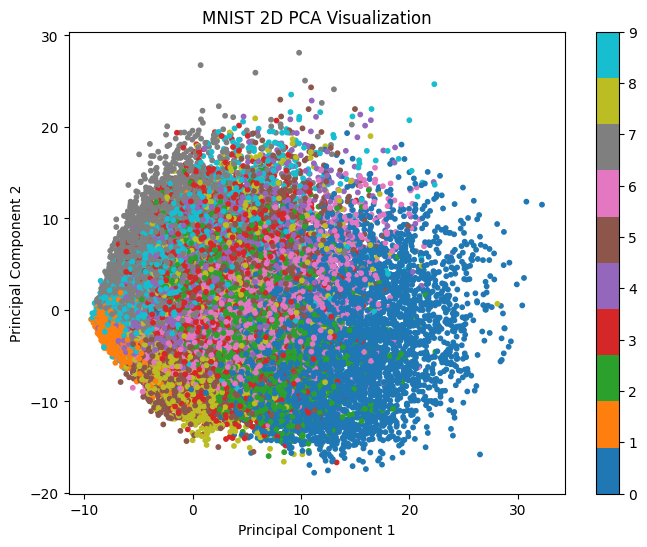

In [ ]:
pca_2d = PCA(n_components=2)
X_train_2d = pca_2d.fit_transform(X_train_scaled)

plt.figure(figsize=(8,6))
scatter = plt.scatter(
    X_train_2d[:, 0],
    X_train_2d[:, 1],
    c=y_train,
    cmap='tab10',
    s=10
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("MNIST 2D PCA Visualization")
plt.colorbar(scatter)
plt.show()